In [1]:
# Через переменные окружения (до импорта TF)
import os
os.environ["OMP_NUM_THREADS"] = "4"        # OpenMP потоки
os.environ["TF_NUM_INTRAOP_THREADS"] = "4"
os.environ["TF_NUM_INTEROP_THREADS"] = "2"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import shutil
from collections import Counter
import tensorflow.keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

In [3]:
# Проверка GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f'✅ GPU: {gpus[0].name}')
else:
    print('⚠️ GPU не найден, используется CPU')

print(f'TensorFlow: {tf.__version__}')

✅ GPU: /physical_device:GPU:0
TensorFlow: 2.12.0


In [4]:
# Параметры
DATASET_PATH = '/home/jupyter/project/tiny'  
IMG_SIZE = (224, 224)      # ResNet входной размер
BATCH_SIZE = 8
EPOCHS1 = 10
EPOCHS2 = 10
EPOCHS3 = 5
VALIDATION_SPLIT = 0.2
SEED = 42

In [5]:
# Загрузка тренировочных данных
train_ds = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Загрузка валидационных данных
val_ds = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Информация о датасете
CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)
print(f'Классы ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Батчей в train: {len(train_ds)}')
print(f'Батчей в val:   {len(val_ds)}')

Found 14027 files belonging to 28 classes.
Using 11222 files for training.
Found 14027 files belonging to 28 classes.
Using 2805 files for validation.
Классы (28): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'nothing', 'space']
Батчей в train: 1403
Батчей в val:   351


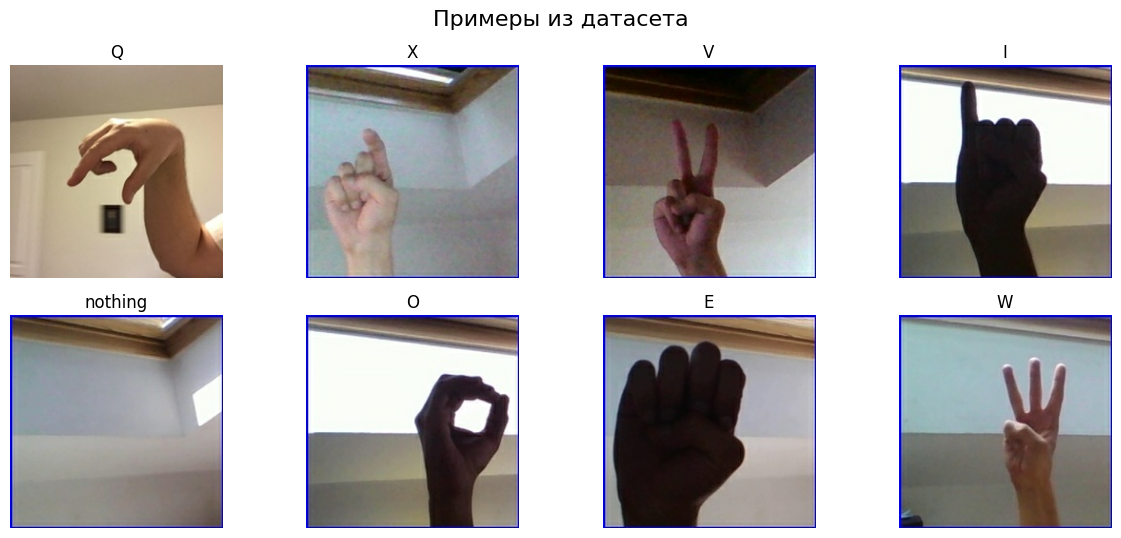

In [6]:
plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(min(12, BATCH_SIZE)):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        label_idx = np.argmax(labels[i])
        plt.title(CLASS_NAMES[label_idx], fontsize=12)
        plt.axis('off')
plt.suptitle('Примеры из датасета', fontsize=16)
plt.tight_layout()
plt.show()


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

# Аугментация данных
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
])

def prepare(ds, augment=False):
    # Нормализация для ResNet
    ds = ds.map(
        lambda x, y: (tf.keras.applications.resnet50.preprocess_input(x), y),
        num_parallel_calls=AUTOTUNE
    )
    if augment:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=AUTOTUNE
        )
    return ds.cache().prefetch(buffer_size=AUTOTUNE)

train_ds = prepare(train_ds, augment=False).cache()
val_ds = prepare(val_ds, augment=False).cache()

print('✅ Данные подготовлены')


✅ Данные подготовлены


In [8]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = tf.keras.layers.Rescaling(1./255)(inputs)
x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)
x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)
x = tf.keras.layers.Conv2D(128, (3, 3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)
x = tf.keras.layers.Conv2D(256, (3, 3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)

outputs = tf.keras.layers.Dense(28, activation='softmax')(x)

In [9]:
model = tf.keras.Model(inputs=inputs, outputs=outputs)

In [10]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=["accuracy"])

In [11]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 54, 54, 64)       0         
 2D)                                                         

In [12]:
# Колбэки
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    )
]

print('🚀 1й этап обучение слоёв...')
history1 = model.fit(
    train_ds,
    epochs=EPOCHS1,
    validation_data=val_ds,
    callbacks=callbacks
)

🚀 1й этап обучение слоёв...
Epoch 1/10
1403/1403 [==============================] - ETA: 0s - loss: 2.6238 - accuracy: 0.2326
Epoch 1: val_accuracy improved from -inf to 0.48449, saving model to best_model.keras
1403/1403 [==============================] - 50s 30ms/step - loss: 2.6238 - accuracy: 0.2326 - val_loss: 1.7100 - val_accuracy: 0.4845 - lr: 0.0010
Epoch 2/10
1401/1403 [============================>.] - ETA: 0s - loss: 1.2216 - accuracy: 0.6144
Epoch 2: val_accuracy improved from 0.48449 to 0.68378, saving model to best_model.keras
1403/1403 [==============================] - 23s 16ms/step - loss: 1.2212 - accuracy: 0.6147 - val_loss: 1.0298 - val_accuracy: 0.6838 - lr: 0.0010
Epoch 3/10
1401/1403 [============================>.] - ETA: 0s - loss: 0.7328 - accuracy: 0.7674
Epoch 3: val_accuracy improved from 0.68378 to 0.75223, saving model to best_model.keras
1403/1403 [==============================] - 23s 16ms/step - loss: 0.7326 - accuracy: 0.7672 - val_loss: 0.8019 - val_

In [13]:
model.save_weights('/home/jupyter/project/Split/original_best_phase1.weights.h5')
val_loss_before, val_acc_before = model.evaluate(val_ds, verbose=0)
print(f"📊 Точность: {val_acc_before:.4f}")

📊 Точность: 0.8381


In [14]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
              loss='categorical_crossentropy',
              metrics=["accuracy"])

In [15]:
print('🚀 2й этап обучение слоёв...')
history2 = model.fit(
    train_ds,
    epochs=EPOCHS2,
    validation_data=val_ds,
    callbacks=callbacks
)

🚀 2й этап обучение слоёв...
Epoch 1/10
1403/1403 [==============================] - ETA: 0s - loss: 0.1436 - accuracy: 0.9558
Epoch 1: val_accuracy improved from 0.83815 to 0.84100, saving model to best_model.keras
1403/1403 [==============================] - 25s 17ms/step - loss: 0.1436 - accuracy: 0.9558 - val_loss: 0.6744 - val_accuracy: 0.8410 - lr: 1.0000e-06
Epoch 2/10
1401/1403 [============================>.] - ETA: 0s - loss: 0.1394 - accuracy: 0.9598
Epoch 2: val_accuracy improved from 0.84100 to 0.84456, saving model to best_model.keras
1403/1403 [==============================] - 23s 16ms/step - loss: 0.1393 - accuracy: 0.9598 - val_loss: 0.6677 - val_accuracy: 0.8446 - lr: 1.0000e-06
Epoch 3/10
1401/1403 [============================>.] - ETA: 0s - loss: 0.1290 - accuracy: 0.9618
Epoch 3: val_accuracy improved from 0.84456 to 0.84635, saving model to best_model.keras
1403/1403 [==============================] - 23s 16ms/step - loss: 0.1293 - accuracy: 0.9618 - val_loss: 0.

In [16]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-9),
              loss='categorical_crossentropy',
              metrics=["accuracy"])

In [17]:
print('🚀 3й этап обучение слоёв...')
history3 = model.fit(
    train_ds,
    epochs=EPOCHS3,
    validation_data=val_ds,
    callbacks=callbacks
)

🚀 3й этап обучение слоёв...
Epoch 1/5
1401/1403 [============================>.] - ETA: 0s - loss: 0.1043 - accuracy: 0.9681
Epoch 1: val_accuracy did not improve from 0.85312
1403/1403 [==============================] - 24s 16ms/step - loss: 0.1042 - accuracy: 0.9682 - val_loss: 0.6460 - val_accuracy: 0.8531 - lr: 1.0000e-09
Epoch 2/5
1401/1403 [============================>.] - ETA: 0s - loss: 0.0968 - accuracy: 0.9705
Epoch 2: val_accuracy did not improve from 0.85312
1403/1403 [==============================] - 22s 16ms/step - loss: 0.0967 - accuracy: 0.9705 - val_loss: 0.6460 - val_accuracy: 0.8531 - lr: 1.0000e-09
Epoch 3/5
1401/1403 [============================>.] - ETA: 0s - loss: 0.1081 - accuracy: 0.9681
Epoch 3: val_accuracy did not improve from 0.85312
1403/1403 [==============================] - 22s 16ms/step - loss: 0.1080 - accuracy: 0.9681 - val_loss: 0.6460 - val_accuracy: 0.8531 - lr: 1.0000e-09
Epoch 4/5
1401/1403 [============================>.] - ETA: 0s - loss: 0

In [18]:
val_loss_before, val_acc_before = model.evaluate(val_ds, verbose=0)
print(f"📊 Точность: {val_acc_before:.4f}")

📊 Точность: 0.8531


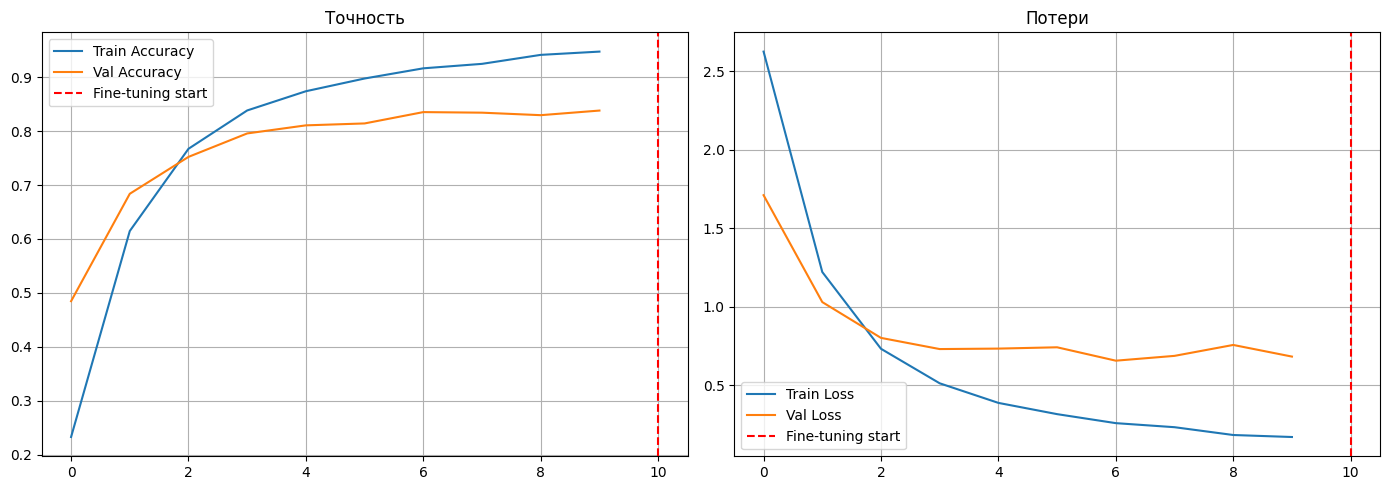

In [19]:
def plot_history(history1, history2=None, history3=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Объединить историю
    acc = history1.history['accuracy']
    val_acc = history1.history['val_accuracy']
    loss = history1.history['loss']
    val_loss = history1.history['val_loss']
    
    if history2:
        acc += history2.history['accuracy']
        val_acc += history2.history['val_accuracy']
        loss += history2.history['loss']
        val_loss += history2.history['val_loss']

    if history3:
        acc += history3.history['accuracy']
        val_acc += history3.history['val_accuracy']
        loss += history3.history['loss']
        val_loss += history3.history['val_loss']
    
    epochs_range = range(len(acc))
    
    # График точности
    ax1.plot(epochs_range, acc, label='Train Accuracy')
    ax1.plot(epochs_range, val_acc, label='Val Accuracy')
    ax1.axvline(x=len(history1.history['accuracy']),
                color='red', linestyle='--', label='Fine-tuning start')
    ax1.set_title('Точность')
    ax1.legend()
    ax1.grid(True)
    
    # График потерь
    ax2.plot(epochs_range, loss, label='Train Loss')
    ax2.plot(epochs_range, val_loss, label='Val Loss')
    ax2.axvline(x=len(history1.history['loss']),
                color='red', linestyle='--', label='Fine-tuning start')
    ax2.set_title('Потери')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history(history1)

              precision    recall  f1-score   support

           A       0.75      0.75      0.75        89
           B       0.79      0.84      0.82       111
           C       0.88      0.89      0.89        94
           D       0.90      0.86      0.88       101
           E       0.81      0.87      0.84        91
           F       0.91      0.86      0.89        96
           G       0.81      0.86      0.84       102
           H       0.85      0.83      0.84        92
           I       0.90      0.79      0.84       104
           J       0.88      0.92      0.90        92
           K       0.81      0.94      0.87       101
           L       0.88      0.87      0.87        99
           M       0.69      0.78      0.73        96
           N       0.80      0.74      0.77       111
           O       0.93      0.90      0.91       115
           P       0.96      0.97      0.97       101
           Q       0.91      0.93      0.92        92
           R       0.89    

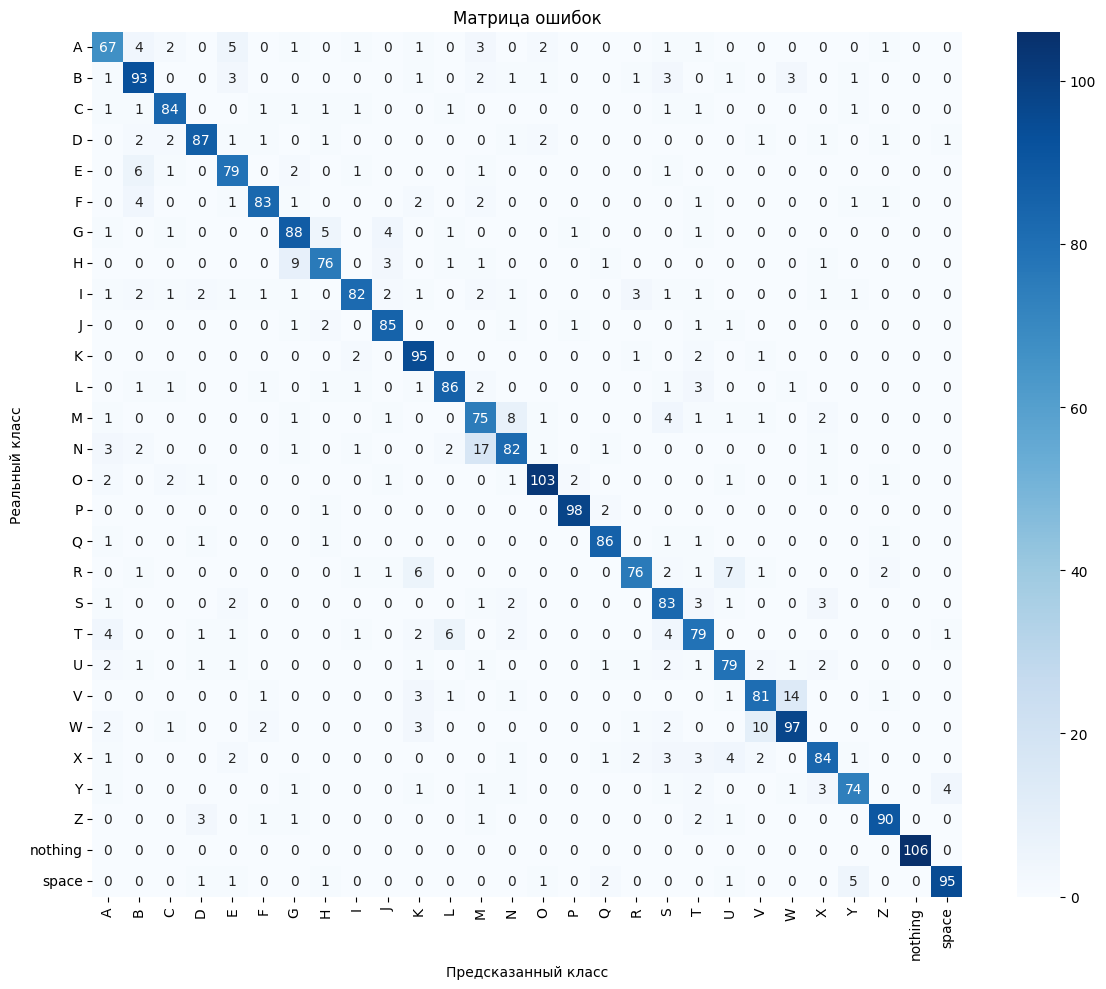

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Предсказания
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

# Отчёт
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Матрица ошибок
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            cmap='Blues')
plt.title('Матрица ошибок')
plt.ylabel('Реальный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

In [21]:
model.save('/home/jupyter/project/Split/sign_language_split.keras')